# (20) Feeder: Rotating MNIST

host = ```mach```, device = ```cuda:1```

**Motivation**: <br>

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from utils.animation import show_movie
from figures.imgs import plot_weights


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## RotatingMNISTFeeder

### Large: $\Delta \theta = 8.0$

In [3]:
cfg = ConfigPoisVAE(dataset='MNIST+rotate')
tr = Trainer(IPVAE(cfg), ConfigTrain(), device=device)

In [4]:
print(cfg.feeder_cfg)

{'theta_0': None, 'delta_theta': 8.0}

#### Test speed

In [5]:
def run(feeder, T=32):
    x_rot = []
    for t in range(T):
        x_rot.append(feeder[t])
    x_rot = torch.cat(x_rot, dim=1)
    return x_rot

In [6]:
feeder = tr.get_feeder(seed=123)

In [7]:
%timeit run(feeder)

74.8 ms ± 2.59 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


#### Make movie

In [8]:
T_two_full_rotations = int(2 * 360 / cfg.feeder_cfg['delta_theta'])
T_two_full_rotations

90

In [9]:
feeder = tr.get_feeder(seed=123, flatten=False)
frames = run(feeder, T=T_two_full_rotations)
frames.shape

torch.Size([200, 90, 28, 28])

In [10]:
from utils.animation import show_movie

show_movie(frames[0], max_n=-1, figsize=(3.5, 2.0))

#### make plots: random $\theta_0$

In [11]:
feeder = tr.get_feeder(seed=123)
feeder.theta_0, feeder.delta_theta

(245.64667076933165, 8.0)

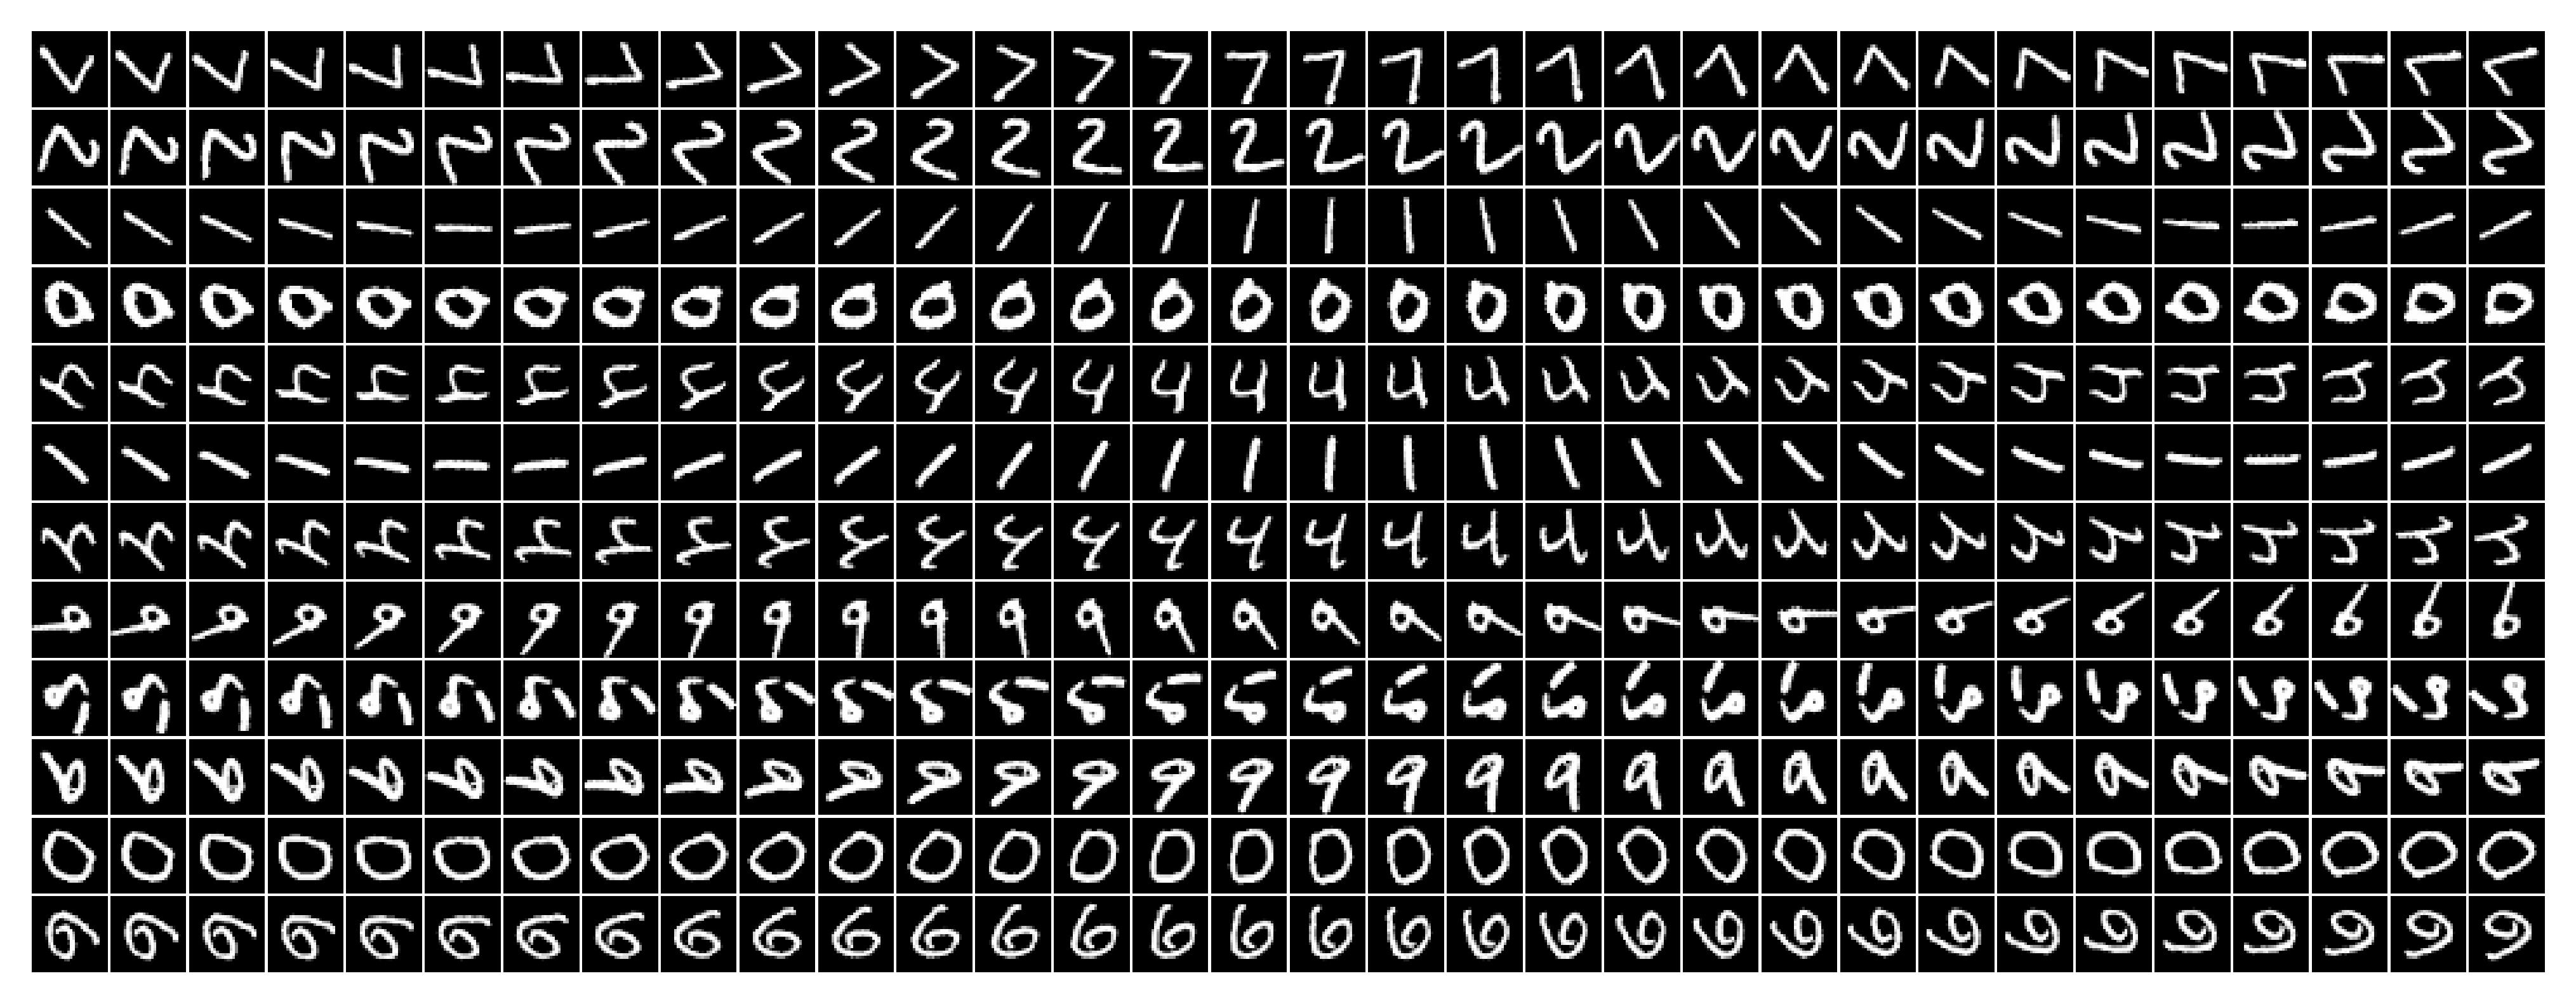

In [12]:
x_rot = run(feeder, 32)

num = 12
x2p = x_rot[:num].view(-1, 28, 28)
_ = plot_weights(x2p, method='none', nrows=num, dpi=500)

#### make plots: fixed $\theta_0 = 0$

In [13]:
feeder = tr.get_feeder(seed=123, theta_0=0)
feeder.theta_0, feeder.delta_theta

(0.0, 8.0)

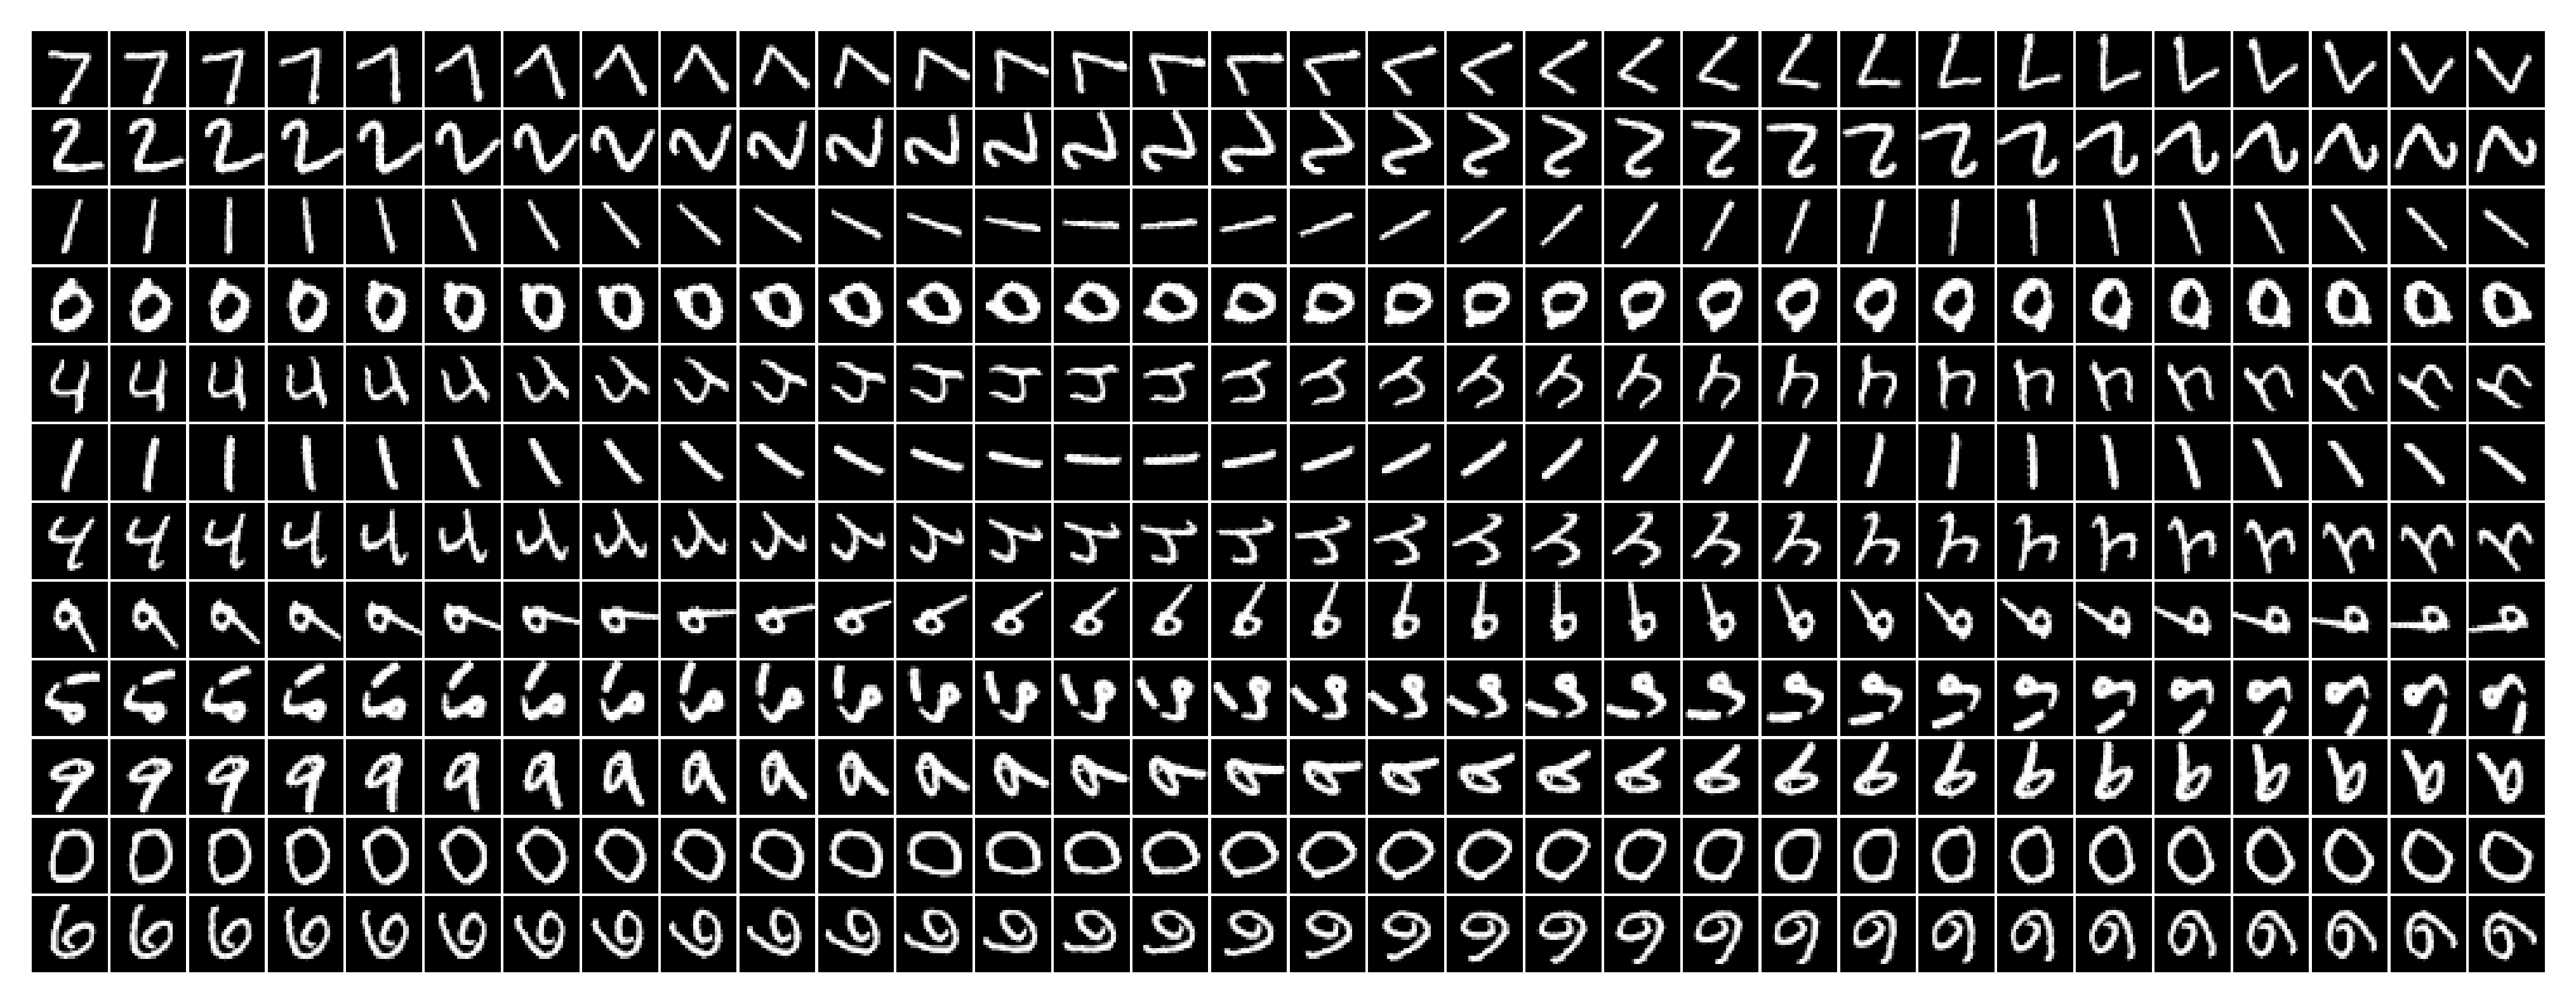

In [14]:
x_rot = run(feeder, 32)

num = 12
x2p = x_rot[:num].view(-1, 28, 28)
_ = plot_weights(x2p, method='none', nrows=num, dpi=500)

#### Plot variance

In [15]:
var_samples = torch.var(frames, dim=1)
var_all = torch.var(frames, dim=[0, 1])

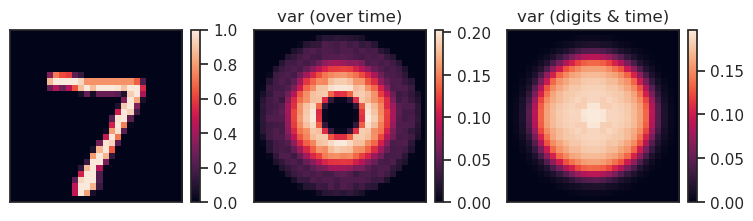

In [16]:
i = 0

ims = []
fig, axes = create_figure(1, 3, (7.5, 2.1), 'all', 'all')
ims.append(axes[0].imshow(tonp(feeder.x[i].squeeze())))
ims.append(axes[1].imshow(tonp(var_samples[i])))
ims.append(axes[2].imshow(tonp(var_all)))

axes[1].set_title('var (over time)')
axes[2].set_title('var (digits & time)')

for im, ax in zip(ims, axes):
    plt.colorbar(im, ax=ax)
remove_ticks(axes, False)

### Medium: $\Delta \theta = 4.0$

In [17]:
delta_theta = 4.0
cfg = ConfigPoisVAE(dataset='MNIST+rotate', kws_feeder={'delta_theta': delta_theta})
tr = Trainer(IPVAE(cfg), ConfigTrain(), device=device)

In [18]:
print(cfg.feeder_cfg)

{'delta_theta': 4.0, 'theta_0': None}

#### Make movie

In [19]:
T_two_full_rotations = int(2 * 360 / cfg.feeder_cfg['delta_theta'])
T_two_full_rotations

180

In [20]:
feeder = tr.get_feeder(seed=123, flatten=False)
frames = run(feeder, T=T_two_full_rotations)
frames.shape

torch.Size([200, 180, 28, 28])

In [21]:
from utils.animation import show_movie

show_movie(frames[0], max_n=-1, figsize=(3.5, 2.0))

#### make plots: random $\theta_0$

In [22]:
feeder = tr.get_feeder(seed=123)
feeder.theta_0, feeder.delta_theta

(245.64667076933165, 4.0)

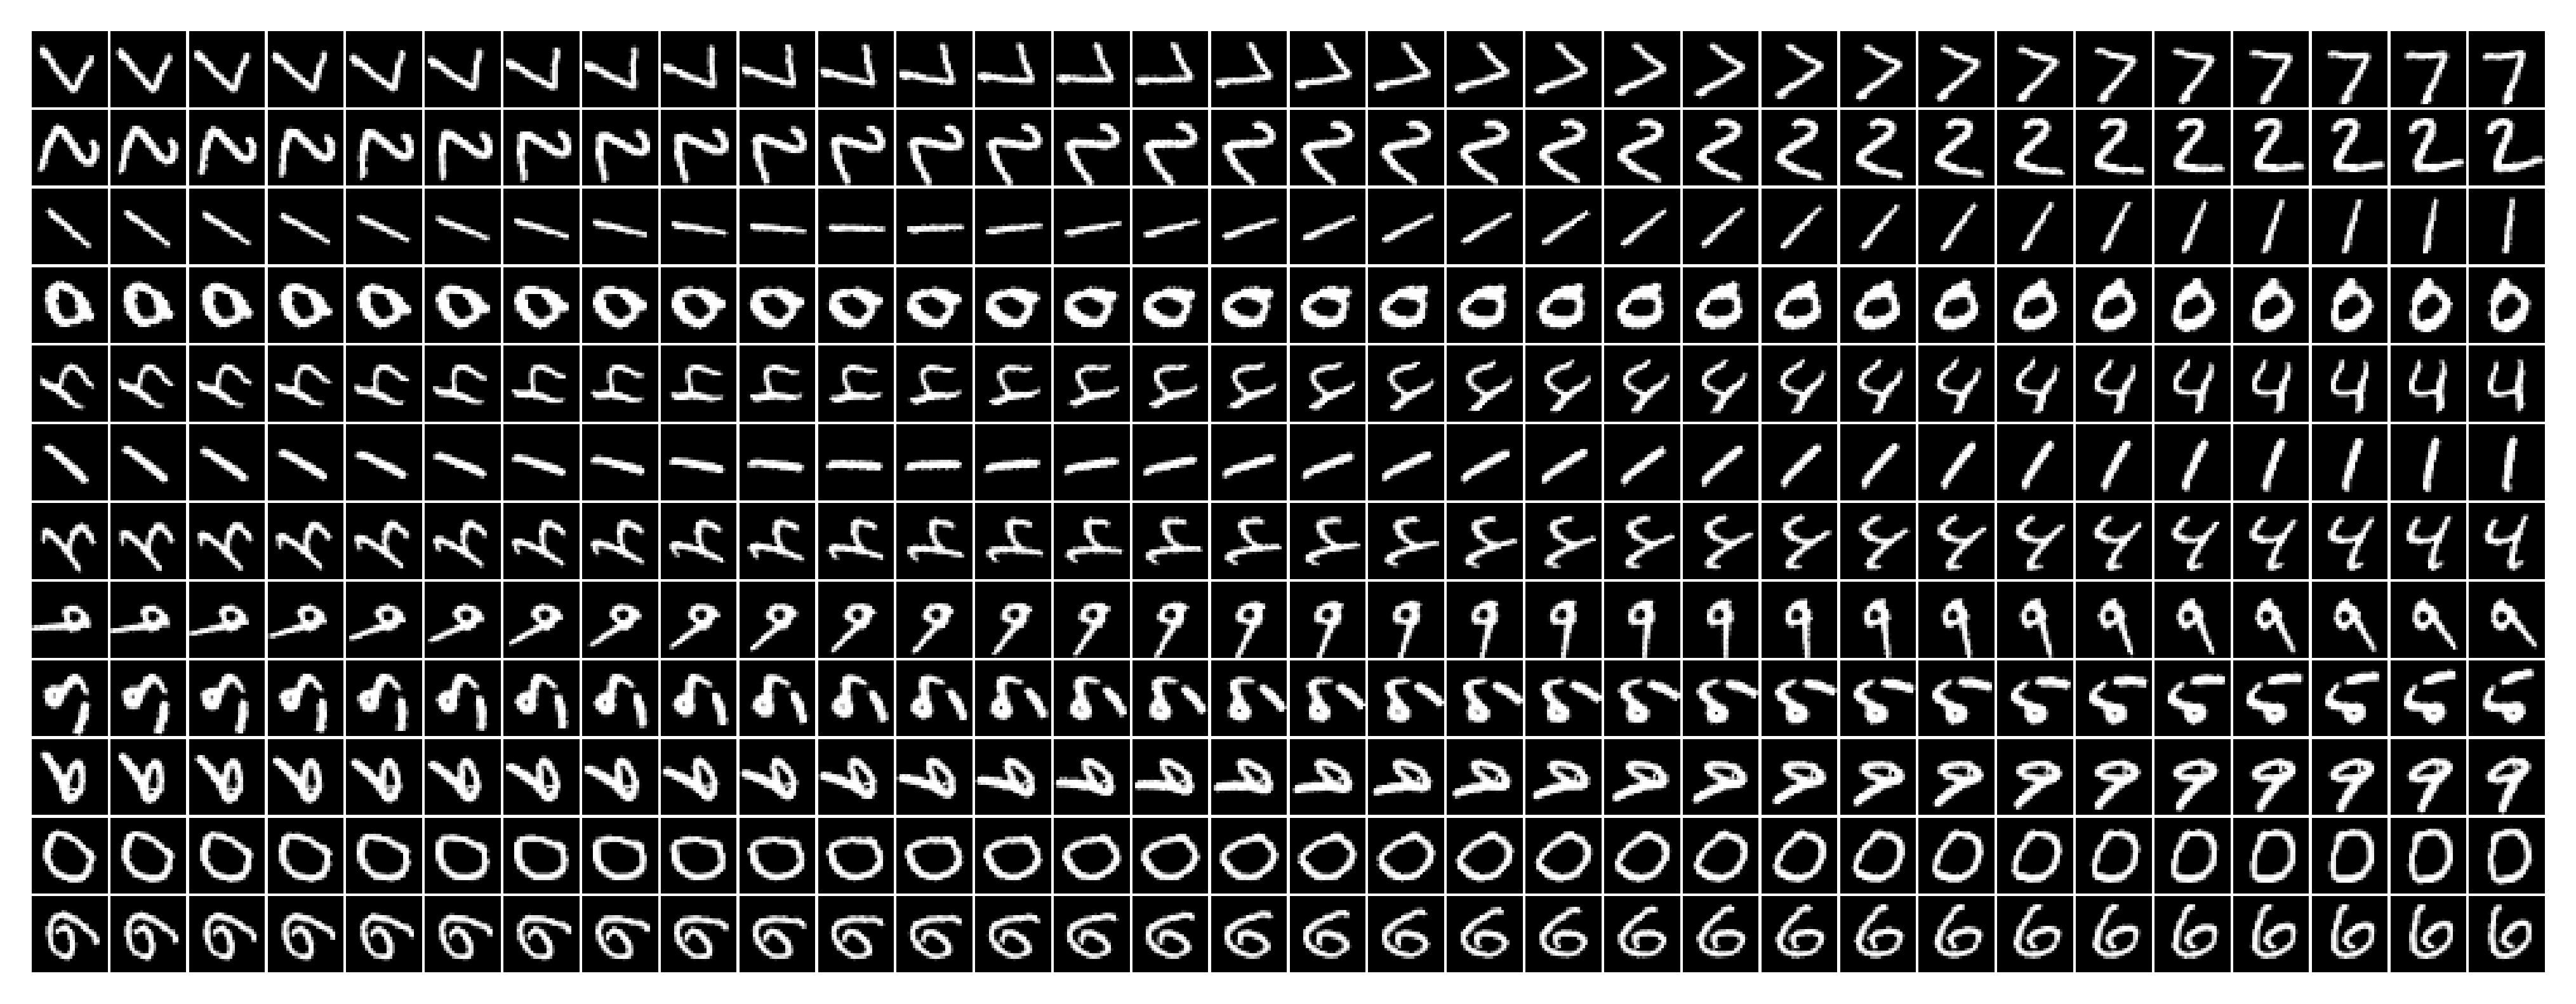

In [23]:
x_rot = run(feeder, 32)

num = 12
x2p = x_rot[:num].view(-1, 28, 28)
_ = plot_weights(x2p, method='none', nrows=num, dpi=500)

#### make plots: fixed $\theta_0 = 0$

In [24]:
feeder = tr.get_feeder(seed=123, theta_0=0)
feeder.theta_0, feeder.delta_theta

(0.0, 4.0)

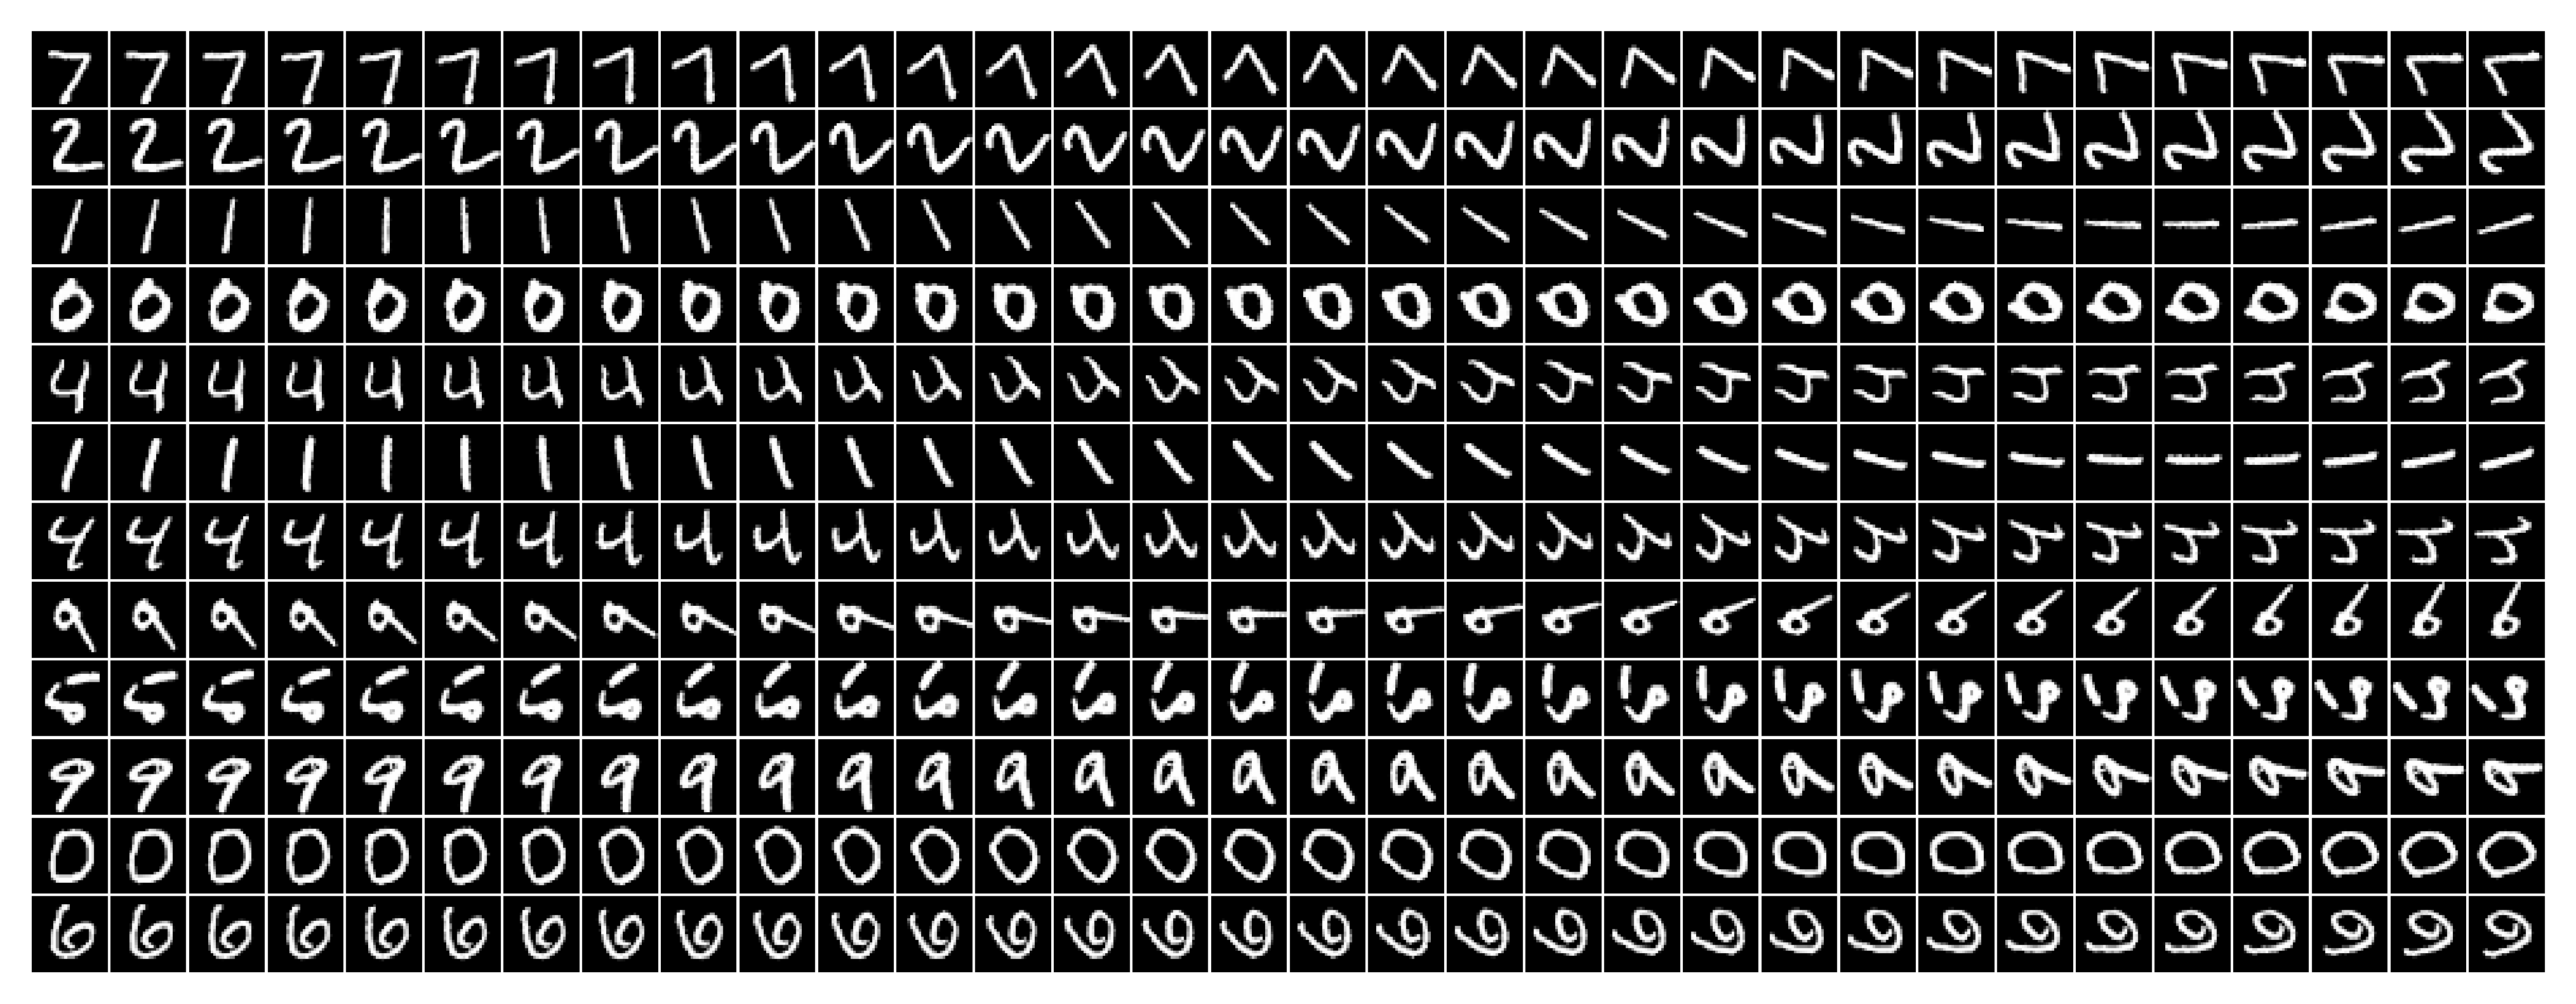

In [25]:
x_rot = run(feeder, 32)

num = 12
x2p = x_rot[:num].view(-1, 28, 28)
_ = plot_weights(x2p, method='none', nrows=num, dpi=500)

#### Plot variance

In [26]:
var_samples = torch.var(frames, dim=1)
var_all = torch.var(frames, dim=[0, 1])

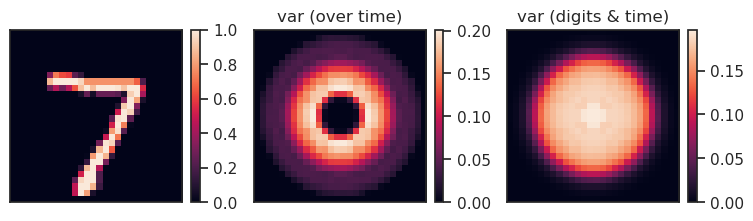

In [27]:
i = 0

ims = []
fig, axes = create_figure(1, 3, (7.5, 2.1), 'all', 'all')
ims.append(axes[0].imshow(tonp(feeder.x[i].squeeze())))
ims.append(axes[1].imshow(tonp(var_samples[i])))
ims.append(axes[2].imshow(tonp(var_all)))

axes[1].set_title('var (over time)')
axes[2].set_title('var (digits & time)')

for im, ax in zip(ims, axes):
    plt.colorbar(im, ax=ax)
remove_ticks(axes, False)